In [1]:
import numpy as np
import pandas as pd
import sklearn

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# Assignment 2: Observational studies of causal effects


In this assignment, you will perform inverse-propensity weigthing (IPW) estimation of the average causal effect of mothers smoking during pregnancy on children being born with low birth weight. 

You will use a data set on twin births for this purpose, with data on mothers and the twins, which can be downloaded from the Canvas assignment. Two text files containing the descriptions of variables and their types can also be downloaded. 

* The intervention of interest ($T$) in this problem is smoking status '''tobacco'''.
* The binary outcome ($Y$) is defined as at least *one* of the twins having birth weight less than 2200 grams, represented in the feature '''low_bw'''.

The data set is based on the one used by Louizos et al. in their paper "Causal Effect Inference with Deep Latent-Variable Models": https://github.com/AMLab-Amsterdam/CEVAE/blob/master/datasets/TWINS

**Note:** *The original data set has been modified for pedagogical purposes. Do not use the data set from the github repository above.*

## Problem 1 — Warmup

* Load the data file '''TWINS_2025.pkl''' into a data frame


In [2]:
# Load the dataset
df = pd.read_pickle('TWINS_2025.pkl')

# Twin US births in 1989-1991.
#   covar_desc_2025.txt: Description of covariates
#   covar_type_2025.txt: Description of covariate types

In [3]:
# Visualize the dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 52091 entries, 0 to 71344
Data columns (total 54 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   pldel          52068 non-null  float64
 1   birattnd       52032 non-null  float64
 2   brstate        52091 non-null  int64  
 3   stoccfipb      52091 non-null  int64  
 4   mager8         52091 non-null  int64  
 5   ormoth         52091 non-null  int64  
 6   mrace          52091 non-null  int64  
 7   meduc6         52091 non-null  int64  
 8   dmar           52091 non-null  int64  
 9   mplbir         52091 non-null  int64  
 10  mpre5          51130 non-null  float64
 11  adequacy       50273 non-null  float64
 12  orfath         52091 non-null  int64  
 13  frace          52091 non-null  int64  
 14  birmon         52091 non-null  int64  
 15  gestat10       52091 non-null  int64  
 16  csex           52091 non-null  int64  
 17  anemia         52091 non-null  int64  
 18  cardiac    

In [4]:
# Visualize sorted list of unique values for each variable
for col in sorted(df.columns):
    unique_values = df[col].dropna().unique()
    unique_values = np.sort(unique_values)
    print(f"{col}: {unique_values}")

adequacy: [1. 2. 3.]
alcohol: [0 1]
anemia: [0 1]
birattnd: [1. 2. 3. 4. 5.]
birmon: [ 1  2  3  4  5  6  7  8  9 10 11 12]
bord_0: [1. 2.]
bord_1: [1. 2.]
brstate: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 55 57 59]
brstate_reg: [0 1 2 3 4 5 6 7 8]
cardiac: [0 1]
chyper: [0 1]
crace: [1 2 3 4 5 6 7 8 9]
csex: [0 1]
data_year: [89 90 91]
dfageq: [0 1 2 3 4 5 6 7]
diabetes: [0 1]
dlivord_min: [ 1  2  3  4  5  6  7  8  9 10 11 12 13]
dmar: [0 1]
drink5: [0 1 2 3 4]
dtotord_min: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
eclamp: [0 1]
feduc6: [1 2 3 4 5]
frace: [1 2 3 4 5 6 7 8 9]
gestat10: [ 1  2  3  4  5  6  7  8  9 10]
hemo: [0 1]
herpes: [0 1]
hydra: [0 1]
incervix: [0 1]
infant_id_0: [     1      7     11 ... 279057 279060 279062]
infant_id_1: [     0      6     10 ... 279058 279059 279061]
low_bw: [False  True]
lung: [0 1]
mager8: [1 2 3 4 5 6 7 8]
meduc6: [1

In [5]:
# Identify continuous and categorical variables
cont_cols = [
    'alcohol',
    'anemia', 'cardiac', 'chyper', 'diabetes', 'eclamp', 'hemo', 'herpes', 'hydra', 'incervix', 'lung', 'othermr', 'phyper', 'renal', 'rh', 'uterine', 
    'bord_0', 'bord_1', 'csex',
    'dmar', 'feduc6', 'meduc6',
    'drink5', 'gestat10',
    'mort_0', 'mort_1',
    'pre4000', 'preterm'
]
cat_cols = [
    'adequacy', 'nprevistq',
    'birattnd',
    'birmon', 'data_year', 'brstate', 'brstate_reg', 'pldel', 'stoccfipb', 'stoccfipb_reg',
    'crace', 'dfageq', 'frace', 'mager8', 'mplbir', 'mplbir_reg', 'mpre5', 'mrace', 'orfath', 'ormoth',
    'dlivord_min', 'dtotord_min',
]

In [6]:
from sklearn.impute import SimpleImputer

# Perform imputation to handle missing values

# Median imputation for continuous variables
median_imputer = SimpleImputer(strategy='median', missing_values=np.nan)
df[cont_cols] = median_imputer.fit_transform(df[cont_cols])
# Mode imputation for categorical variables
mode_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = mode_imputer.fit_transform(df[cat_cols])

# Remove rows with missing treatment or outcome
df = df.dropna(subset=["tobacco", "low_bw"])

# Convert boolean variables to integer type
df["tobacco"] = df["tobacco"].astype(int)
df["low_bw"] = df["low_bw"].astype(int)

# Create one-hot encoding
# pd.get_dummies one-hot encodes object or category dtype columns
#                drop_first=True to avoid multicolinearity
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

* Compute the difference-in-means estimator of the average causal effect (ACE) of smoking on at least one twin having low birth weight, *without adjusting for confounding*. That is, the difference in average outcomes for smokers and non-smokers. 

In [7]:
# Compute the difference-in-means ACE estimate
T = df["tobacco"]                       # risk factor, tobacco use (1:smoker, 0:non-smoker)
Y = df["low_bw"]                        # at least one twin with low birth weight (<2200g) (1:yes, 0:no)
ACE = Y[T==1].mean() - Y[T==0].mean()   # average causal effect of tobacco on low birth weight
print(f"Difference-in-means ACE estimate: {ACE:.4f}")

Difference-in-means ACE estimate: 0.1633


In [8]:
# Average Causal Effect (ACE) estimate fifference in average outcomes between treated and untreated groups.
# ACE > 0 indicates that treatment increases the probability of the outcome
# However, because the data are observational, this difference may reflect confounding rather than a true causal effect.

Confounding can be introduced by variables that are causal of both the treatment and the outcome. Therefore, candidate confounders must be potentially causal of the treatment assignment $T$—they have to be "pre-treatment". No variables that were determined after (or as a result of) a mom starting smoking are candidate confounders. Such variables are called "post-treatment" variables. The covariates are described in the file supplied on Canvas.  

* Go through the covariates and categorize the entire list into: "Pre-treatment variables", "Post-treatment variables", and "Ambiguous". There is not one right answer here, so justify your reasoning for cases where you are unsure. 

* Identify potential confounders: variables that could have affected a mother's propensity to smoke *and* the likelihood that they have a low birth-weight child. Call this set of variables $A$. These will be your adjustment set.

Recall that an ideal adjustment set $A$ results in *conditional exchangeability*, that subjects are as-if-randomly assigned to treatment, in terms of their potential outcomes, once we condition on $A$:
$$
\forall a : Y(t) \perp T \mid A=a
$$

* Is your selected set likely to satisfy conditional exchangeability? Why/why not?

Go through the covariates and categorize the entire list into: "Pre-treatment variables", "Post-treatment variables", and "Ambiguous".

Answer: 

- 'infant_id_0' and 'infant_id_1' are the birth identifiers
- 'tobacco' is the variable indicating treatment, that is a mom starting smoking during pregnancy
- 'low_bw' is the variable indicating the outcome

All other variables are covariates that can be classified as pre-treatment or post-treatment variables. 

"Pre-treatment variables"
- Pre-pregnancy alcohol intake ('alcohol', 'drink5'): historical.
- Pre-existing maternal conditions ('anemia', 'eclamp', 'hemo', 'herpes', 'hydra', 'incervix', 'othermr', 'phyper', 'pre4000', 'preterm', 'rh', 'uterine'): historical.
- Birth state ('brstate', 'brstate_reg'): state of birth, fixed.
- Twin race and sex ('crace', 'csex'): fixed at conception, before treatment.
- Father’s characteristics ('dfageq', 'feduc6', 'frace', 'orfath'): historical.
- Births before twins ('dlivord_min', 'dtotord_min'): historical.
- Mother's characteristics ('dmar', 'mager8', 'meduc6', 'mplbir', 'mplbir_reg', 'mrace', 'ormoth'): historical.

"Post-treatment variables" 
- Medical person attending birth ('birattnd'): determined after treatment just before birth.
- Month and year of birth ('birmon', 'data_year'): determined after treatment at birth.
- Birth order of twins ('bord_0', 'bord_1'): determined after treatment at birth.
- Gestational age at delivery ('gestat10'): determined after treatment at birth.
- Infant mortality ('mort_0', 'mort_1'): outcome after treatment at birth.
- Place of delivery ('pldel'):  determined after treatment just before birth.
- Actual birth state and county ('stoccfipb', 'stoccfipb_reg'): determined after treatment at birth.

"Ambiguous" variables are chronic health conditions that could either have been present before the mother ever began smoking, or could have developed as a consequence of prior smoking years. 
- Pre-existing maternal conditions that could worsen due to smoking ('cardiac', 'chyper', 'diabetes', 'lung', 'renal').
- Adequacy of care and prenatal visits may be influenced by complication caused by smoking ('adequacy', 'mpre5', 'nprevistq').


Identify potential confounders.

Answer: 

Confounders are pre-treatment variables influencing both the treatment, the mather smoking, and the outcome, low birth weight. Considering that, potential confounders may be:

- Mother's characteristics ('mager8', 'meduc6', 'mplbir', 'mplbir_reg', 'mrace'): demographics may be associated with smoking propensity and birth outcomes.
- Pre-pregnancy alcohol intake ('alcohol', 'drink5'): maternal lifestyle may be associated with smoking propensity and birth outcomes.


In [9]:
# Define adjustment set
covariates_adj = [
  'mager8', 'meduc6', 'mplbir', 'mplbir_reg', 'mrace',
  'alcohol', 'drink5'
]

Is your selected set likely to satisfy conditional exchangeability? Why/why not?

Answer: 

For the conditional exchangeability to be satisfied, the potential outcome, $Y(t)$ have to be independent on the treatment group, $T$, for the selected adjustment set, $A$ of confounders: 
$Y(t) \;\perp\!\!\!\perp\; T \mid A=a$. 

The adjustment set satisfy conditional exchangeability, meaning: $p(Y(t))=\int p(Y \mid T=t, A=a)p(A=a)da$. 

Specifically, in this case, the adjustment set includes maternal demographics and lifestile behaviours, paternal demographics, and maternal pregnancy history. These variables are likely confounders because they are likely influencing both the treatment, mother smoking during pregnancy, and the outcome, low birth weight. However, some relevant confounders may be unmeasured (uncollected genetic risks, socioeconomic variables) so conditional exchangeability is likely satisfied but not guaranteed.  

## Problem 2 — Propensity score modeling

### Fitting the propensity score

* Estimate the propensity score $p(T=1\mid A=a)$ as a function of your adjustment set $A$. *Hint: Use a probabilistic classifier to predict the treatment variable from the adjustment set. Any Python package is permitted.*
    * Use train/test splitting with 30% left for the test set so that you can evaluate your model later. 

In [10]:
# Estimate the propensity score as a function of your adjustment set
# Create the new adjustment set including all dummies for each categorical variable
covariates_adj_all = []
for col in covariates_adj:
    matched_cols = [c for c in df.columns if c.startswith(col + '_')] # Find all dummy columns that start with the original column name + '_'
    if matched_cols:
        covariates_adj_all.extend(matched_cols)
    else:
        covariates_adj_all.append(col)
A = df[covariates_adj_all].copy()
# Use train/test splitting with 30% left for the test set so that you can evaluate your model later
A_train, A_test, T_train, T_test = train_test_split(A, T, test_size=0.3, random_state=2, stratify=T)
# Use a probabilistic classifier to predict the treatment variable from the adjustment set
prob_class_model = LogisticRegression(max_iter=1000)
prob_class_model.fit(A_train, T_train)
T_test_pred = prob_class_model.predict_proba(A_test)[:, 1] # propensity scores P(T=1|X)

### Evaluating the propensity score

* What is the discriminative ability (AUROC) of your propensity score estimate? 
* What do you conclude from this number? Is the model a good model of the propensity score?

In [11]:
# Compute the discriminative ability (AUROC) of your propensity score estimate
AUROC = roc_auc_score(T_test, T_test_pred)
print(f"AUROC for treatment model: {AUROC:.4f}")

AUROC for treatment model: 0.7311


In [12]:
# AUC tells how well the model discriminates treatment and control using the adjustment set. 
# AUROC close to 0.5 → model not informative
# AUROC high (0.7–0.9) → model distinguishes well
# AUROC too high above 0.9 → may indicate overfitting

What do you conclude from this number? Is the model a good model of the propensity score?

Answer: 

The Area Under the Receiver Operating Characteristic curve (AUROC) describes how well the propensity score model discriminates between treated and untreated individuals based on a set of covariates. An AUROC of 0.7311 means the model can distinguish smokers from non-smokers in ~73% of cases based on the defined adjustment set.

### Inspecting the fitted score

* Plot a histogram of the estimated propensity score for the test-set subjects
* Plot a histogram of the inverse of the estimated propensity score for the test-set subjects

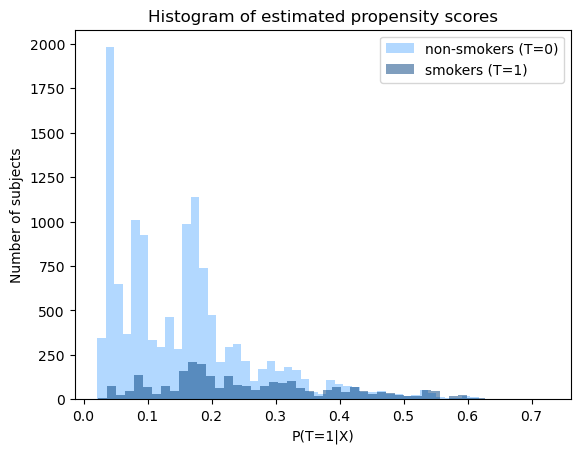

In [13]:
# Plot a histogram of the estimated propensity score for the test-set subjects
plt.hist(T_test_pred[T_test==0], bins=50, alpha=0.5, color='#66b3ff', label='non-smokers (T=0)')
plt.hist(T_test_pred[T_test==1], bins=50, alpha=0.5, color='#003f7f', label='smokers (T=1)')
plt.xlabel('P(T=1|X)')
plt.ylabel('Number of subjects')
plt.title('Histogram of estimated propensity scores')
plt.legend()
plt.show()

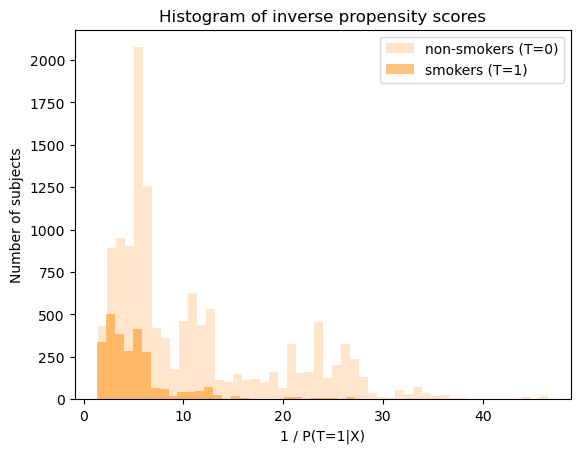

In [14]:
# Plot a histogram of the inverse of the estimated propensity score for the test-set subjects
plt.hist(1/ T_test_pred[T_test==0], bins=50, alpha=0.5, color='#ffcc99', label='non-smokers (T=0)')
plt.hist(1/ T_test_pred[T_test==1], bins=50, alpha=0.5, color='#ff8c00', label='smokers (T=1)')
plt.xlabel('1 / P(T=1|X)')
plt.ylabel('Number of subjects')
plt.title('Histogram of inverse propensity scores')
plt.legend()
plt.show()

* Read about [probability calibration](https://scikit-learn.org/1.5/modules/calibration.html) and plot the test-set calibration curve for your fitted propensity model. You may use e.g., the scikit-learn package for this.
  * Are there parts of the curve that have higher error? If so, what are possible reasons? Compare the calibration curve to your histogram of the propensity score. 

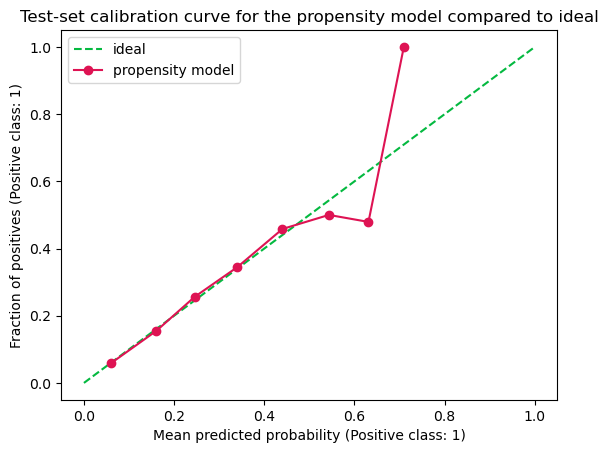

In [15]:
# Plot the test-set calibration curve for your fitted propensity model
prob_true, prob_pred = calibration_curve(T_test, T_test_pred, n_bins=10)
plt.plot([0, 1], [0, 1], linestyle='--', color="#04b940", label='ideal')
plt.plot(prob_pred, prob_true, marker='o', color="#de1353", label='propensity model')
plt.xlabel('Mean predicted probability (Positive class: 1)')
plt.ylabel('Fraction of positives (Positive class: 1)')
plt.title('Test-set calibration curve for the propensity model compared to ideal')
plt.legend()
plt.show()

Are there parts of the curve that have higher error? If so, what are possible reasons? Compare the calibration curve to your histogram of the propensity score. 

Answer: 

The propensity model (red line) closely follows the ideal calibration (green line) up to around 0.5, meaning the propensity model predicts well the true probabilities up to around 0.5. Beyond 0.5, the propensity model lies below the ideal calibration, meaning the model tends to overerestimate the treatment probability. Also, beyond 0.7, the propensity model lies above the ideal calibration, meaning the model tends to udererestimate the treatment probability. The histogram shows highest bins for low propensity scores, meaning the majority of the subjects have low propensity scores. Therefore, the overestimation or underestimation at higher probabilities likely occurs because there are fewer subjects in the high propensity score range, making it difficult for the model to fully capture complex covariate patterns in this range.

### Inverse-propensity weighting estimation
* Estimate the average causal effect (ACE) of smoking $T$ on having one birth-weight twin $Y$ using inverse-propensity weighting (IPW) as described in Lecture 5.1 and lecture notes. *Note: Different adjustment sets will yield different estimates. We are more interested in your ability to apply methods correctly than you getting a specific value of the estimate.*
  * Use the estimated propensity score in place of the true score. (since the true propensity is unknown). 
  * Use the test set to estimate the effect

Tip: If you are getting high variance in your estimate of the ACE, consider clipping or normalizing the propensity weights.
When clipping, you make sure that the weights are in [0, C] for some constant C by setting the weight to C for any value that is larger.
When normalizing, you make sure that the mean of the weights is 1 by dividing weights by the mean.

In [16]:
# Estimate the ACE of smoking, T, on having one birth-weight twin, Y, using IPW
# Use the estimated propensity score
p = T_test_pred
# Use the test set
t = T_test.values
y = df.loc[A_test.index, "low_bw"].values
# Compute weights
w_1 = t / p
w_0 = (1 - t) / (1 - p)
# Estimate the ACE using IPW
ACE_ipw = np.mean(w_1 * y) - np.mean(w_0 * y)
# Visualize the ACE estimate
print(f"ACE estimate: {ACE_ipw:.4f}")


ACE estimate: 0.1159


Is the IPW ACE estimate stable across data splits? Report an average of estimates computed for 10 randomly sampled train/test splits. 

In [17]:
# Compute an average of ACE estimates for 10 randomly sampled tranin/test splits
n_splits = 10
ACE_splits = []
for split in range(n_splits):
    # Train/test split
    A_train_split, A_test_split, T_train_split, T_test_split = train_test_split(A, T, test_size=0.3, random_state=split, stratify=T)
    # Instantiate probabilistic classifier
    prob_class_model_split = LogisticRegression(max_iter=1000)
    prob_class_model_split.fit(A_train_split, T_train_split)
    # Estimate propensity scores for test set
    T_test_split_pred = prob_class_model_split.predict_proba(A_test_split)[:, 1]
    # Estimate ACE using IPW on the test set
    p_split = T_test_split_pred
    t_split = T_test_split.values
    y_split = df.loc[A_test_split.index, "low_bw"].values
    w_1_split = t_split / p_split
    w_0_split = (1 - t_split) / (1 - p_split)
    ACE_split = np.mean(w_1_split * y_split) - np.mean(w_0_split * y_split)
    ACE_splits.append(ACE_split)
# Average ACE with standard deviation over splits
ACE_ipw_avg = np.mean(ACE_splits)
ACE_ipw_sd = np.std(ACE_splits)
print(f"Average ACE over {n_splits} splits: {ACE_ipw_avg:.4f} ± {ACE_ipw_sd:.4f}")

Average ACE over 10 splits: 0.1382 ± 0.0118


Is the IPW ACE estimate stable across data splits? 

Answer: 

The standard deviation of the average IPW ACE estimate across 10 randomly smpled train/test splits, is ~0.0118, which is small relatively to the mean ACE estimate of ~0.1382. Since the standard deviation correspond to ~8.5% of the mean ACE estimate, the IPW ACE is fairly stable across data splits.

## Problem 3 — Analysis

* Try to improve the propensity model AUROC by including more variables in your adjustment set $A$ from the category you labeled "post-treatment" and refitting your model. 
    * How do the AUROCs compare before and after expanding the adjustment set?

In [18]:
# Expand adjustment set with post-treatment variables
covariates_pt = [
    'lung'
]
covariates_pt_all = []
for col in covariates_pt:
    matched_cols = [c for c in df.columns if c.startswith(col + '_')] # Find all dummy columns that start with the original column name + '_'
    if matched_cols:
        covariates_pt_all.extend(matched_cols)
    else:
        covariates_pt_all.append(col)
A_exp = df[covariates_adj_all + covariates_pt_all].copy()
# Drop rows with NaNs in the expanded adjustment set
A_exp = A_exp.dropna()
T_exp = T.loc[A_exp.index]
# Train/test split
A_train_exp, A_test_exp, T_train_exp, T_test_exp = train_test_split(A_exp, T_exp, test_size=0.3, random_state=2)
# Probabilistic classifier to predict the treatment variable from the adjustment set
prob_class_model_exp = LogisticRegression(max_iter=1000)
prob_class_model_exp.fit(A_train_exp, T_train_exp)
T_test_exp_pred = prob_class_model_exp.predict_proba(A_test_exp)[:,1]
# Compute the discriminative ability (AUROC)
AUROC_exp = roc_auc_score(T_test_exp, T_test_exp_pred)
print(f"AUROC with expanded adjustment set: {AUROC_exp:.4f} (initial adjustment set: {AUROC:.4f})")


AUROC with expanded adjustment set: 0.7233 (initial adjustment set: 0.7311)


How do the AUROCs compare before and after expanding the adjustment set?

Answer: 

In theory, expanding the adjustment set is expected to improve the AUROC because additional relevant covariates can help reduce confounding and capture more variability related to the outcome, improving model discrimination. However, after multiple attempts to expand the set using different combinations of pre-treatment and ambiguous variables, no improvement in AUROC was observed. In this specific case, when only the 'lung' variable was added, the AUROC slightly decreased from 0.7311 to 0.7233. This behavior may indicate that the added variables are only weakly associated with the outcome or are highly correlated with variables already in the adjustment set, meaning that their contribution to model discrimination is little.

* If a propensity model has higher AUROC than another, is it always better for inverse-propensity weighting? Why/why not? *Hint: think of the assumptions/conditions needed for the IPW strategy to identify the ACE. Compare e.g., to a randomized controlled trial.*

If a propensity model has higher AUROC than another, is it always better for inverse-propensity weighting?

Answer:

The Area Under the Receiver Operating Characteristic curve (AUROC) describes how well the propensity score model discriminates between treated and untreated individuals based on a set of covariates. However, a higher AUROC does not necessarily mean the model is better for inverse-propensity weighting (IPW). 

In IPW, each individual is weighted as: $w_i = \frac{p(T=t)}{p(T=t \mid A=a_i)}$. For a binary treatment, these weights can be expressed as: $w_i = \frac{T_i}{p_i} + \frac{1-T_i}{1-p_i}$. 



So, if the propensity scores are poorly-calibrated or too close to 0 or 1, the weights can become very large, making the estimate unstable. A model can have a high AUROC (good discrimination) but still be miscalibrated, overconfident, or produce extreme propensities

* Compare the results of the IPW analysis to the difference-in-means estimate. What do you conclude? 

In [19]:
# Estimate the ACE of smoking, T, on having one birth-weight twin, Y, using IPW
p_exp = T_test_exp_pred
t_exp= T_test_exp.values
y_exp = df.loc[A_test_exp.index, "low_bw"].values
w_1_exp = t_exp / p_exp
w_0_exp = (1 - t_exp) / (1 - p_exp)
ACE_ipw_exp = np.mean(w_1_exp * y_exp) - np.mean(w_0_exp * y_exp)
# Visualize the ACE estimate and compare to previous estimates
print(f"Difference-in-means ACE estimate: {ACE:.4f}")
print(f"ACE estimate with expanded adjustment set: {ACE_ipw_exp:.4f} (initial adjustment set: {ACE_ipw:.4f})")

Difference-in-means ACE estimate: 0.1633
ACE estimate with expanded adjustment set: 0.1583 (initial adjustment set: 0.1159)


Compare the results of the IPW analysis to the difference-in-means estimate. What do you conclude? 

Answer:

The difference-in-means estimate of the average causal effect (ACE) was 0.1633. Using IPW with the initial adjustment set of pre-treatment variables, the ACE decreased to 0.1159, indicating that part of the ACE estimate was due to confounding. Expanding the adjustment set including post-treatment variables increased the ACE to 0.1583, likely reflecting bias from conditioning on variables affected by treatment.

* How confident are you in the implications of the result? How would you change the data/analysis to improve your confidence?

How confident are you in the implications of the result? How would you change the data/analysis to improve your confidence?

Answer: 

Overall, the IPW estimate using only pre-treatment variables provides a reasonable approximation of the causal effect of maternal smoking on low birth weight. However, the confidence in the causal interpretation is limited by potential unmeasured confounders and the assumptions underlying the propensity score model.

Confidence in the results could be improved by more balanced and better-characterized data, careful adjustment set selection, and robustness analyses. 
As observed in the histogram of propensity scores, there are many more non-smokers (T=0) than smokers (T=1). A more representative and balanced dataset would improve propensity score estimation, reduce variance in the IPW weights, and yield more stable ACE estimates.
Also, the variable descriptions in the dataset are often brief and lack detail. Clearer information about the timing and causal relevance of covariates would allow more accurate classification of pre-treatment variables and confounders, thereby improving the validity of the adjustment set and strengthening the assumption of conditional exchangeability.
Finally, using alternative causal inference methods combined with sensitivity analyses for unmeasured confounding would provide additional confidence in the results.

#### Disclosure of the use of AI tools

In VS Code, I first read and understood the assignment instructions. I then wrote a comment in a Python cell with a specific task description and reviewed the code suggested by Copilot. After an initial analysis, I consulted the Python documentation for the classes, methods, and functions used. After understanding how they work, I critically evaluated Copilot's suggestions, added comments, and made adjustments. Whenever something was unclear, I used ChatGPT as a guide to deeper understand the reasoning behind certain choices and functions.